In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage


In [2]:
def sigmoid(x):
    s = 1 / (1 + np.exp(-x))
    return s

In [3]:
def intialize_zero(dim):
    w = np.zeros([dim, 1])
    b = 0.0
    return w, b

In [4]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost =  -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    dw = 1/m * np.dot(X, (A - Y).T)
    db = 1/m * np.sum(A - Y)
    cost = np.squeeze(np.array(cost))
    grads = {
        "dw" : dw,
        "db" : db
    }
    return grads, cost

In [5]:
def optimize(w, b, X, Y, num_iterations = 100, learning_rate = 0.009, print_cost = False):
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    costs = []

    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw = grads["dw"]
        db = grads["db"]
        w = w - learning_rate * dw
        b = b - learning_rate * db
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print ("Cost after iteration %i: %f" %(i, cost))

    params = {
        "w" : w,
        "b" : b
    }
    grads = {
        "dw" : dw,
        "db" : db
    }
    return params, grads, cost

In [6]:
def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)
    A = sigmoid(np.dot(w.T, X) + b)
    for i in range(A.shape[1]):
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0
    return Y_prediction

In [7]:
def model(X_train, Y_train, x_test, y_test, num_iterations = 2000, learning_rate = 0.5, print_cost = False):
    w, b = intialize_zero(X_train.shape[0])
    params, grads, costs = optimize(w, b ,X_train, Y_train, num_iterations, learning_rate, print_cost)
    w = params["w"]
    b = params["b"]
    Y_prediction_test = predict(w, b, x_test)
    Y_prediction_train = predict(w ,b, X_train)
    if print_cost:
        print("train accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
        print("test accuracy: {} %".format(100 - np.mean(np.abs(Y_prediction_test - y_test)) * 100))
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d

In [8]:
import cv2
import os

def load_and_preprocess_data(folder_path, label, image_size=(64, 64)):
    X = []
    Y = []
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, image_size)
            X.append(img)
            Y.append(label)
            
    return X, Y

print("Loading data.....")
X_train_dogs, Y_train_dogs = load_and_preprocess_data('datasets/train/dogs', 1)
X_train_cats, Y_train_cats = load_and_preprocess_data('datasets/train/cats', 0)
X_test_dogs, Y_test_dogs = load_and_preprocess_data('datasets/test/dogs', 1)
X_test_cats, Y_test_cats = load_and_preprocess_data('datasets/test/cats', 0)
X_train_raw = np.array(X_train_dogs + X_train_cats)
Y_train= np.array(Y_train_dogs + Y_train_cats).reshape(1, -1)

X_test_raw = np.array(X_test_dogs + X_test_cats)
Y_test = np.array(Y_test_dogs + Y_test_cats).reshape(1, -1)

X_train = (X_train_raw.reshape(X_train_raw.shape[0], -1).T) / 255
X_test = (X_test_raw.reshape(X_test_raw.shape[0], -1).T) / 255

Loading data.....


In [9]:

d = model(X_train=X_train, 
          Y_train=Y_train, 
          x_test=X_test,  
          y_test=Y_test, 
          num_iterations=5000, 
          learning_rate=0.005, 
          print_cost=True)
d

Cost after iteration 0: 0.693147
Cost after iteration 100: 1.315895
Cost after iteration 200: 1.257159
Cost after iteration 300: 1.212348
Cost after iteration 400: 1.175054
Cost after iteration 500: 1.142360
Cost after iteration 600: 1.112823
Cost after iteration 700: 1.085703
Cost after iteration 800: 1.060575
Cost after iteration 900: 1.037159
Cost after iteration 1000: 1.015250
Cost after iteration 1100: 0.994682
Cost after iteration 1200: 0.975312
Cost after iteration 1300: 0.957014
Cost after iteration 1400: 0.939675
Cost after iteration 1500: 0.923194
Cost after iteration 1600: 0.907480
Cost after iteration 1700: 0.892453
Cost after iteration 1800: 0.878041
Cost after iteration 1900: 0.864182
Cost after iteration 2000: 0.850821
Cost after iteration 2100: 0.837910
Cost after iteration 2200: 0.825406
Cost after iteration 2300: 0.813275
Cost after iteration 2400: 0.801482
Cost after iteration 2500: 0.790002
Cost after iteration 2600: 0.778810
Cost after iteration 2700: 0.767885
Cost

{'costs': array(0.57076514),
 'Y_prediction_test': array([[0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
         0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0.,
         0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1.,
         0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0.]]),
 'Y_prediction_train': array([

Model y = 1
=> Dog


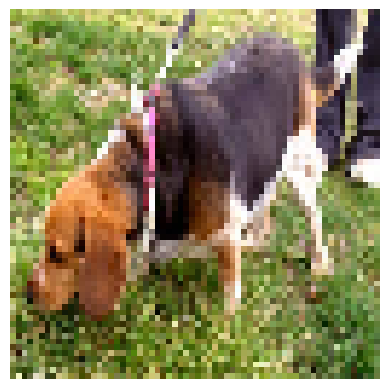

In [10]:
import matplotlib.pyplot as plt

my_image_path = "datasets/test/dogs/dogs_00253.jpg" 
img = cv2.imread(my_image_path)

if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img, (64, 64))
    X_single = img_resized.reshape(64 * 64 * 3, 1) / 255.
    w_trained = d["w"]
    b_trained = d["b"]

    my_prediction = predict(w_trained, b_trained, X_single)

    result = int(np.squeeze(my_prediction))

    print(f"Model y = {result}")
    if result == 1:
        print("=> Dog")
    else:
        print("=> Cat")
        
    plt.imshow(img_resized)
    
    plt.axis('off')
    plt.show()
else:
    print("Cannot read")
